In [1]:
import polars as pl
import pandas as pd

In [ ]:
#import the annotation table of the mgf used as input in the FASST search
annotation_table = pl.read_csv("/.../Carnitine_library_2025_testing_annotation_table.tsv", separator="\t", ignore_errors=True)


In [ ]:
#import matches after the raw_cosine calculation
matches = pl.read_csv("/.../matches_cosine_calculation_output.tsv", separator="\t",
                      ignore_errors=True)

#merge with annotation table
matches = matches.join(annotation_table, on="Scan", how="left")

#calculate deltas
matches = matches.with_columns(
    (pl.col("precursor_mz") - 162.1125).alias("delta")
)

matches = matches.with_columns(
    pl.col("delta").round(2).alias("delta_round")
)

#filter for only matches with cosine_raw >= 0.7
matches = matches.filter(matches["cosine_raw"] >= 0.7)

#create a column scan_USI
matches = matches.with_columns(
    (pl.col("Scan").cast(pl.Utf8) + "_" + pl.col("USI")).alias("scan_USI")
)

# plantMASST

In [ ]:
#import plantmasst
plantmasst = pl.read_csv('/.../plant.tsv', separator='\t', ignore_errors=True)

#create scan_USI
plantmasst = plantmasst.with_columns(
    (pl.col("Scan").cast(pl.Utf8) + "_" + pl.col("USI")).alias("scan_USI")
)

#merge with matches.tsv since it has info on the raw cosine, deltas, etc
plantmasst_merged = plantmasst.join(
    matches.select(["scan_USI", "cosine_raw", "precursor_mz", "delta", "delta_round"]),
    on="scan_USI",
    how="left"
)

#filter for only matches with cosine_raw >= 0.7
plantmasst_merged = plantmasst_merged.filter(plantmasst_merged["cosine_raw"] >= 0.7)

#convert to pandas
plantmasst_merged = plantmasst_merged.to_pandas()

#and finally let's add another annotation column with simplified names (putative explanation if available, or CAR with deltas)
annotation_delta_round = pd.read_csv('/.../Carnitines_library_2025_testing_V2_MassQL_only_annotation_table_delta_round.tsv', sep='\t')
annotation_delta_round = annotation_delta_round.rename(columns={'scans':'Scan'})

plantmasst_merged = pd.merge(plantmasst_merged, annotation_delta_round[['Scan', 'annotation_delta_round']], on='Scan', how='left')

In [6]:
len(plantmasst_merged['annotation_delta_round'].unique())

522

In [7]:
#now let's remove compounds that appear just one or two times

plantmasst_merged = plantmasst_merged.groupby('annotation_delta_round').filter(lambda x: len(x) >= 3)

len(plantmasst_merged['annotation_delta_round'].unique())

358

In [8]:
# Removing the ones that appear 5% in blanks or QCs

# Calculate counts
blank_counts = plantmasst_merged.groupby('annotation_delta_round')['Blank'].value_counts().rename('counts')
qc_counts = plantmasst_merged.groupby('annotation_delta_round')['QC'].value_counts().rename('counts')

# Calculate percentages
blank_percentages = (plantmasst_merged.groupby('annotation_delta_round')['Blank'].value_counts(normalize=True) * 100).rename('percentage')
qc_percentages = (plantmasst_merged.groupby('annotation_delta_round')['QC'].value_counts(normalize=True) * 100).rename('percentage')

# Combine counts and percentages for Blank
blank_results = pd.concat([blank_counts, blank_percentages], axis=1)

# Combine counts and percentages for QC
qc_results = pd.concat([qc_counts, qc_percentages], axis=1)

# Calculate the percentage of 'Blank' = 'Yes' for each 'group_annotation'
blank_yes_percentage = plantmasst_merged.groupby('annotation_delta_round')['Blank'].value_counts(normalize=True).unstack().fillna(0) * 100
qc_yes_percentage = plantmasst_merged.groupby('annotation_delta_round')['QC'].value_counts(normalize=True).unstack().fillna(0) * 100

# Identify 'group_annotation' values where 'Blank' = 'Yes' percentage is greater than 5%
groups_to_exclude_blank = blank_yes_percentage[blank_yes_percentage['Yes'] > 5].index
groups_to_exclude_qc = qc_yes_percentage[qc_yes_percentage['Yes'] > 5].index

# Filter the original DataFrame to exclude these 'group_annotation' values
fastmasst_matches_deltas_microbes = plantmasst_merged[~plantmasst_merged['annotation_delta_round'].isin(groups_to_exclude_blank)]
fastmasst_matches_deltas_microbes = plantmasst_merged[~plantmasst_merged['annotation_delta_round'].isin(groups_to_exclude_qc)]

len(plantmasst_merged['annotation_delta_round'].unique())

358

# Food

In [ ]:
#import foodmasst
foodmasst = pl.read_csv('/.../food.tsv', separator='\t', ignore_errors=True)

#create scan_USI
foodmasst = foodmasst.with_columns(
    (pl.col("Scan").cast(pl.Utf8) + "_" + pl.col("USI")).alias("scan_USI")
)

#merge with matches.tsv since it has info on the raw cosine, deltas, etc
foodmasst_merged = foodmasst.join(
    matches.select(["scan_USI", "cosine_raw", "precursor_mz", "delta", "delta_round"]),
    on="scan_USI",
    how="left"
)

#filter for only matches with cosine_raw >= 0.7
foodmasst_merged = foodmasst_merged.filter(foodmasst_merged["cosine_raw"] >= 0.7)

#convert to pandas
foodmasst_merged = foodmasst_merged.to_pandas()

#and finally let's add another annotation column with simplified names (putative explanation if available, or CAR with deltas)
annotation_delta_round = pd.read_csv('/.../Carnitines_library_2025_testing_V2_MassQL_only_annotation_table_delta_round.tsv', sep='\t')
annotation_delta_round = annotation_delta_round.rename(columns={'scans':'Scan'})

foodmasst_merged = pd.merge(foodmasst_merged, annotation_delta_round[['Scan', 'annotation_delta_round']], on='Scan', how='left')

len(foodmasst_merged['annotation_delta_round'].unique())


349

In [10]:
#now let's remove compounds that appear just one or two times
foodmasst_merged = foodmasst_merged.groupby('annotation_delta_round').filter(lambda x: len(x) >= 3)

len(foodmasst_merged['annotation_delta_round'].unique())

263

# Humans and Rodents

In [ ]:
#import humans and rodents
humans = pl.read_csv('/.../matches_ReDU_humans_cos07.tsv', separator="\t", ignore_errors=True)
rodents = pl.read_csv('/.../matches_ReDU_rodents_cos07.tsv', separator="\t", ignore_errors=True)


In [12]:
#keep only columns that we will need
humans = humans[['Scan', 'delta_round']]
rodents = rodents[['Scan', 'delta_round']]

humans_pd = humans.to_pandas()
rodents_pd = rodents.to_pandas()

#let's get the annotation_delta_round
humans_pd = pd.merge(humans_pd, annotation_delta_round[['Scan', 'annotation_delta_round']], on='Scan', how='left')
rodents_pd = pd.merge(rodents_pd, annotation_delta_round[['Scan', 'annotation_delta_round']], on='Scan', how='left')


In [13]:
#create lists of compounds present in each domain
humans_list = humans_pd['annotation_delta_round'].unique().tolist()
rodents_list = rodents_pd['annotation_delta_round'].unique().tolist()
foods_list = foodmasst_merged['annotation_delta_round'].unique().tolist()
plants_list = plantmasst_merged['annotation_delta_round'].unique().tolist()

# Upset plot

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

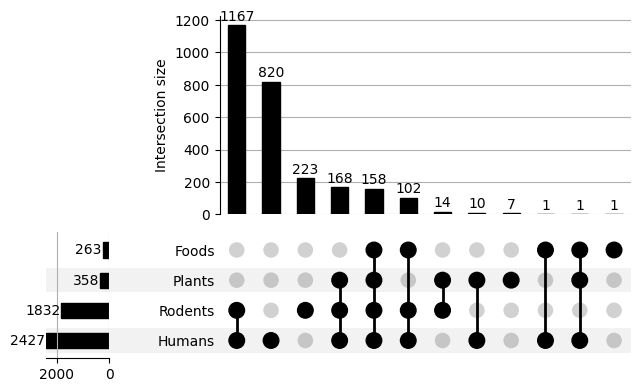

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

# --- clean lists (remove NaNs/None, enforce uniqueness) ---
def _clean_unique(seq):
    s = pd.Series(seq)
    s = s[pd.notna(s)]
    return pd.unique(s).tolist()

humans = _clean_unique(humans_list)
rodents = _clean_unique(rodents_list)
foods  = _clean_unique(foods_list)
plants = _clean_unique(plants_list)

# --- build contents dict -> UpSet data ---
contents = {
    "Humans": humans,
    "Rodents": rodents,
    "Foods": foods,
    "Plants": plants,
}

upset_data = from_contents(contents)

# --- plot (top 30 intersections) ---
up = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality",
    sort_categories_by="cardinality"
)

up.plot()
plt.savefig("/.../upset_domains.pdf")
